In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

import sys  
sys.path.insert(1, '../../python_files/')
import qubits
import pulses

### Transmonin määrittely

In [2]:
E_C = 0.3*2*np.pi #Varausenergia (GHz)
E_J = 8*2*np.pi #Josephsonin energia (GHz)

qubit=qubits.Transmon(E_C,E_J,500)

In [3]:
print("Transmonin yksitoista ensimmäistä energiatasoa (GHz), kun E_0=0")
print(qubit.energies[0:11]-qubit.energies[0])

Transmonin yksitoista ensimmäistä energiatasoa (GHz), kun E_0=0
[  0.          25.48860139  48.57030326  69.5813038   82.4548144
 109.4189376  110.44497738 160.29841201 160.30648659 227.12458838
 227.12460681]


## Simulaatio

In [4]:
f_ef = qubit.energies[2]-qubit.energies[1] #ef-siirtymän taajuus

dim = 7

evolution_eigenbasis=qubits.time_evolution(qubit.H_D_eigbasis(dim))

In [18]:
def find_params(q,A,evolution,f_rabi,AC_stark,lims,scale):

    #Rajat AC-stark siirtymälle
    min_range = lims[0]
    max_range = lims[1]

    f_d = q.frequency #Ajotaajuus
    
    #Arvot eri ajotaajuuksille/AC-stark siirtymille
    pulse_times=[]
    max_e_vals=[]
    max_f_vals=[]
    AC_stark_vals=[]

    for i in range(min_range,max_range):
        print(i)
        delta = AC_stark + i/scale
        if A<0.13:
            sim_vals = pulses.sim_3_part_pulses(f_d+delta,f_ef,A,evolution,dim,f_rabi,t_ramp=5,U_f=20)
        else:
            sim_vals = pulses.sim_3_part_pulses(f_d+delta,f_ef,A,evolution,dim,f_rabi,t_ramp=5,U_f=1)
        AC_stark_vals.append(delta)
        max_e_vals.append(sim_vals[0])
        max_f_vals.append(sim_vals[1])
        pulse_times.append(sim_vals[2])

    plt.figure()
    plt.plot(AC_stark_vals, max_e_vals)
    plt.xlabel("δ$=ω_d-ω_q\ (10^9)$ rad/s")
    plt.ylabel("Maximum e-state probability")
    plt.show()
    
    index=np.argmax(max_e_vals)
    AC_stark=AC_stark_vals[index]
    e_max=max_e_vals[index]
    f_max=max_f_vals[index]
    pi_pulse=pulse_times[index]
    
    return(AC_stark,pi_pulse,[e_max,f_max],max_e_vals)

<>:29: SyntaxWarning: invalid escape sequence '\ '
<>:29: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipykernel_15736/4201514830.py:29: SyntaxWarning: invalid escape sequence '\ '
  plt.xlabel("δ$=ω_d-ω_q\ (10^9)$ rad/s")


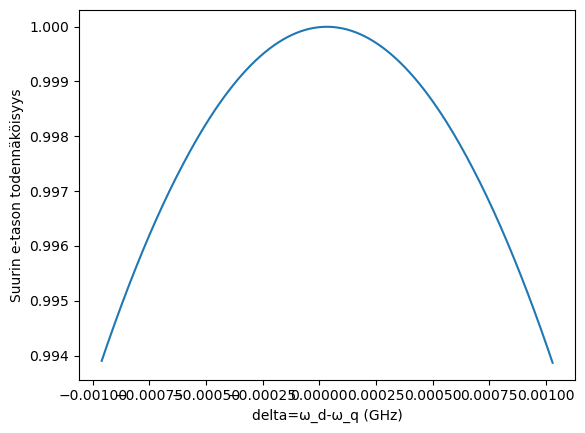

Amplitudi (GHz): 0.012744300694754308
AC-stark siirtymä (GHz): 2.9871900648194566e-05
E-tason suurin todennäköisyys: 0.9999999025746319
Pulssin pituus (ns): 251.57913925957695
Rabi-taajuus (fourier):  0.0020283208289499487


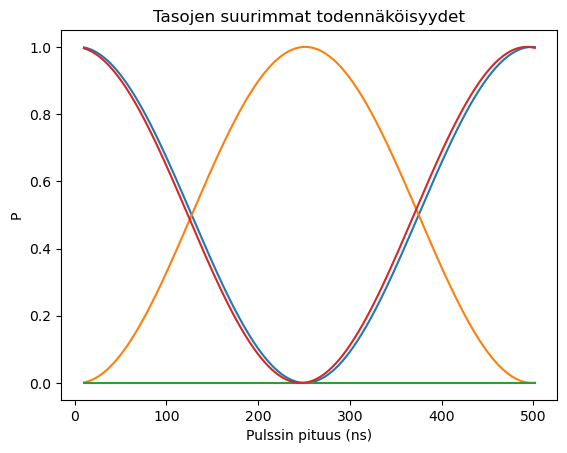

---------------------------------------------


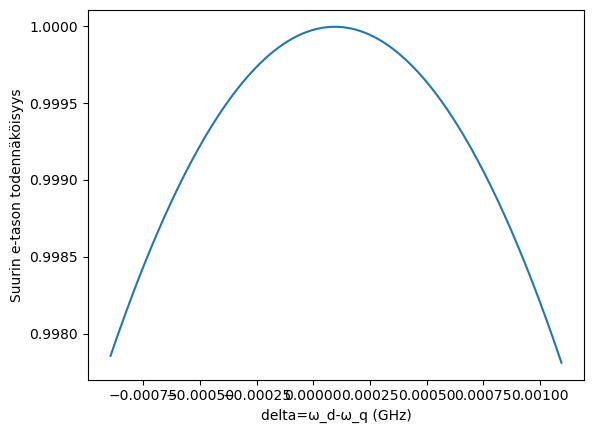

Amplitudi (GHz): 0.021464085380638837
AC-stark siirtymä (GHz): 9.498067552726481e-05
E-tason suurin todennäköisyys: 0.9999996475263531
Pulssin pituus (ns): 150.50995676976984
Rabi-taajuus (fourier):  0.0034161280170806386


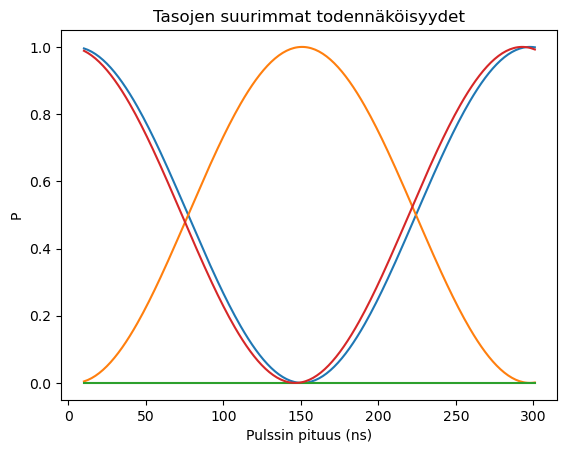

---------------------------------------------


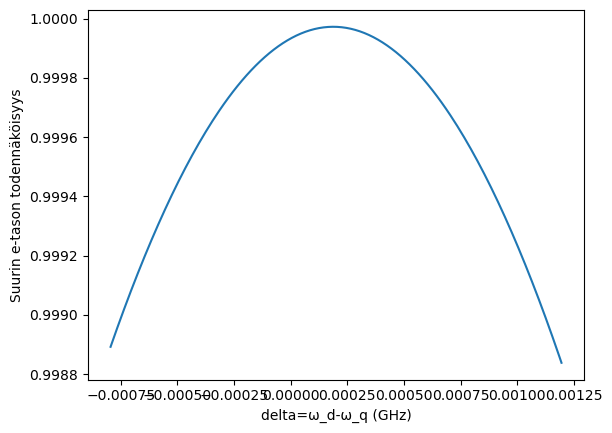

Amplitudi (GHz): 0.030183870066523365
AC-stark siirtymä (GHz): 0.00018467000693786622
E-tason suurin todennäköisyys: 0.9999988750434652
Pulssin pituus (ns): 108.60313147136213
Rabi-taajuus (fourier):  0.004806476652587316


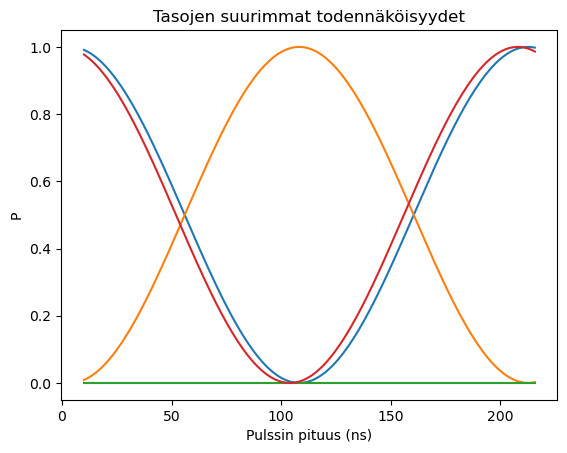

---------------------------------------------


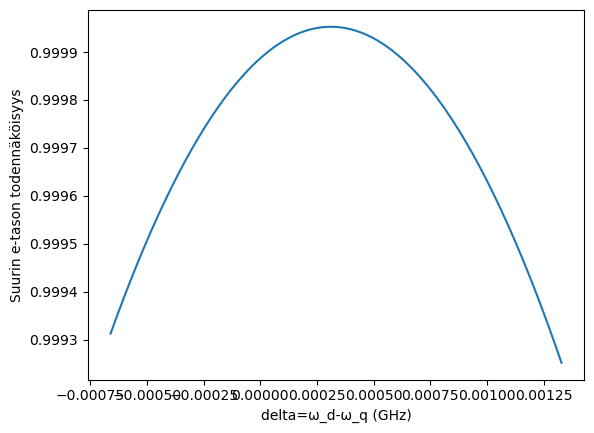

Amplitudi (GHz): 0.03890365475240789
AC-stark siirtymä (GHz): 0.00030893989487999865
E-tason suurin todennäköisyys: 0.9999995598344724
Pulssin pituus (ns): 85.18452118681144
Rabi-taajuus (fourier):  0.0061934138518330364


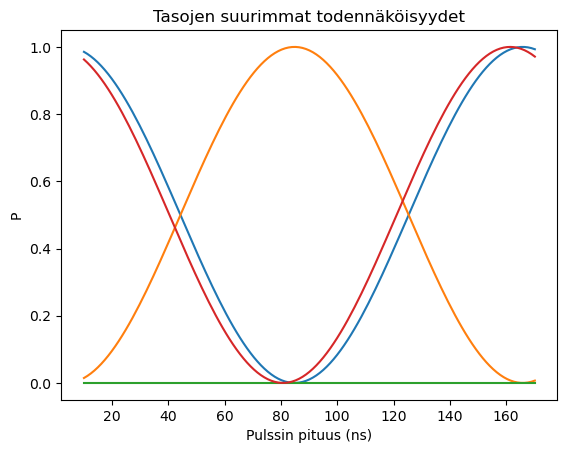

---------------------------------------------


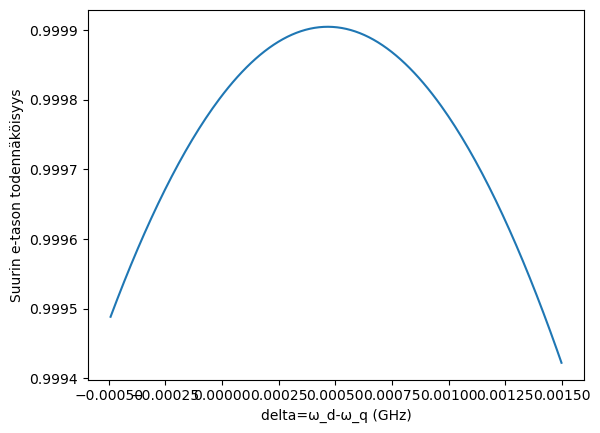

Amplitudi (GHz): 0.04762343943829242
AC-stark siirtymä (GHz): 0.0004677903393536623
E-tason suurin todennäköisyys: 0.9999848424016208
Pulssin pituus (ns): 70.39374719403466
Rabi-taajuus (fourier):  0.007582638046325399


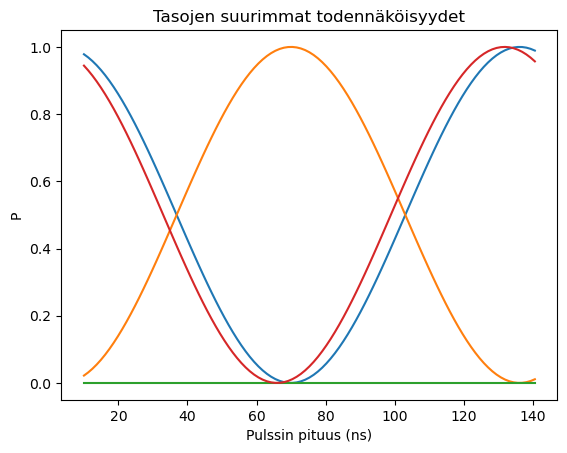

---------------------------------------------


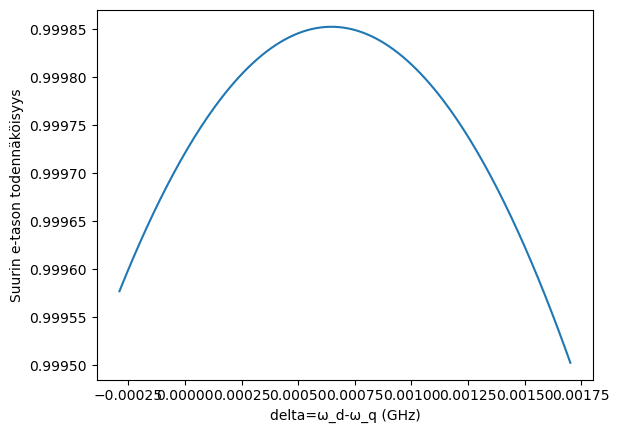

Amplitudi (GHz): 0.05634322412417695
AC-stark siirtymä (GHz): 0.0006512213403588572
E-tason suurin todennäköisyys: 0.9999958723874995
Pulssin pituus (ns): 59.30066332745494
Rabi-taajuus (fourier):  0.008975089709589849


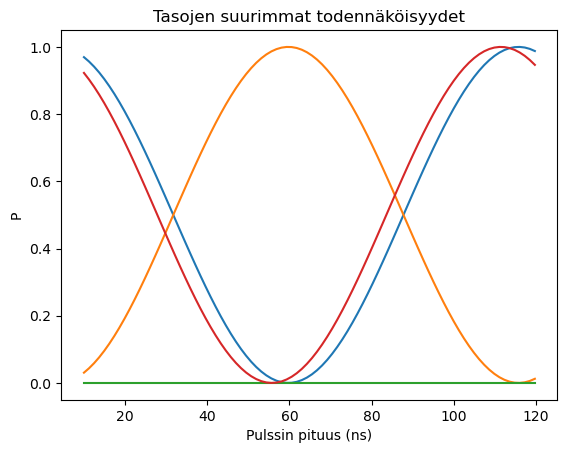

---------------------------------------------


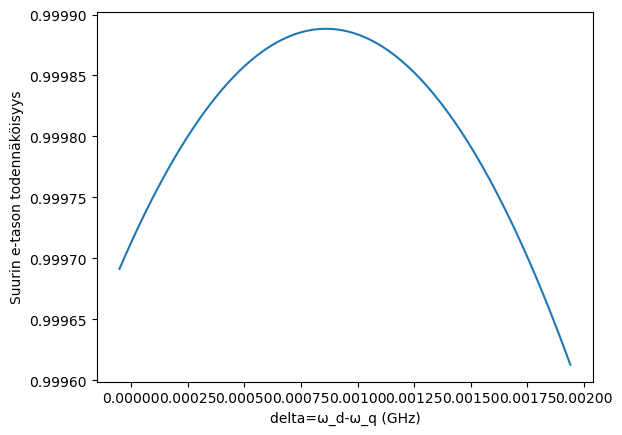

Amplitudi (GHz): 0.06506300881006147
AC-stark siirtymä (GHz): 0.0008592328978955829
E-tason suurin todennäköisyys: 0.9999985690257079
Pulssin pituus (ns): 51.905221850068486
Rabi-taajuus (fourier):  0.010362129386467984


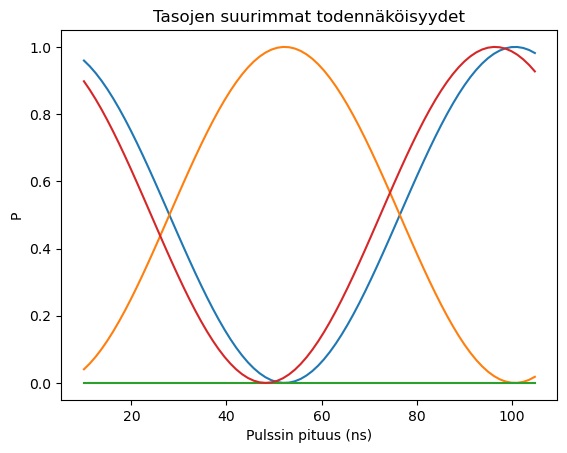

---------------------------------------------


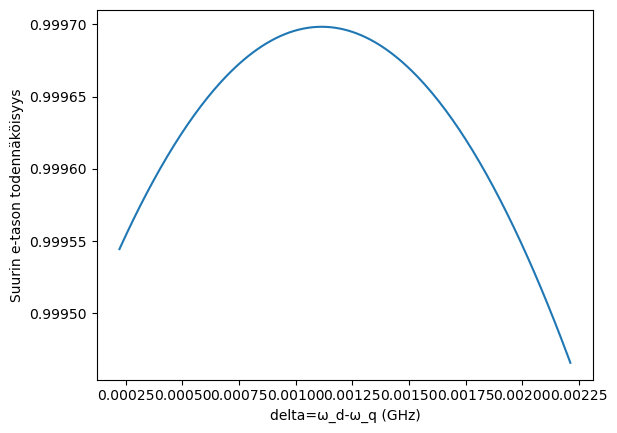

Amplitudi (GHz): 0.073782793495946
AC-stark siirtymä (GHz): 0.0011118250119638402
E-tason suurin todennäköisyys: 0.9999993265534349
Pulssin pituus (ns): 46.974829341745675
Rabi-taajuus (fourier):  0.011758880742277543


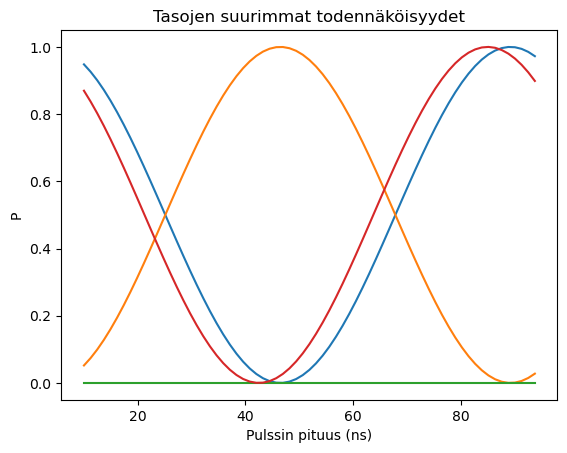

---------------------------------------------


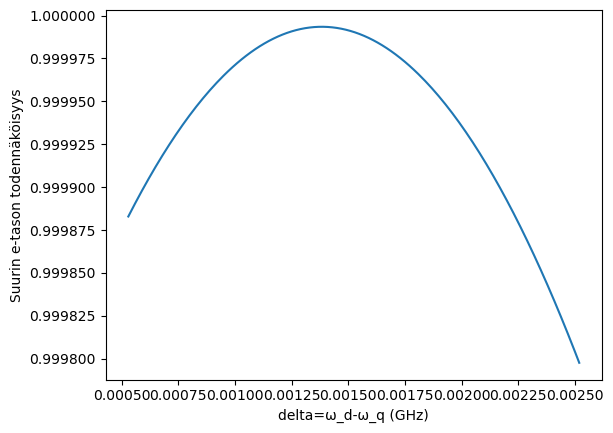

Amplitudi (GHz): 0.08250257818183053
AC-stark siirtymä (GHz): 0.0013789976825636285
E-tason suurin todennäköisyys: 0.9999989442935926
Pulssin pituus (ns): 42.04451621876487
Rabi-taajuus (fourier):  0.013150263785857173


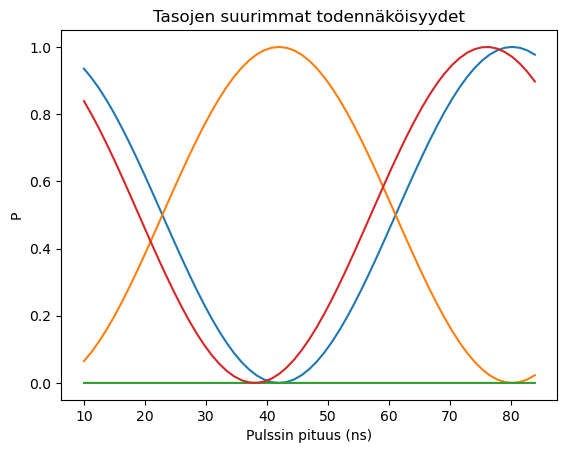

---------------------------------------------


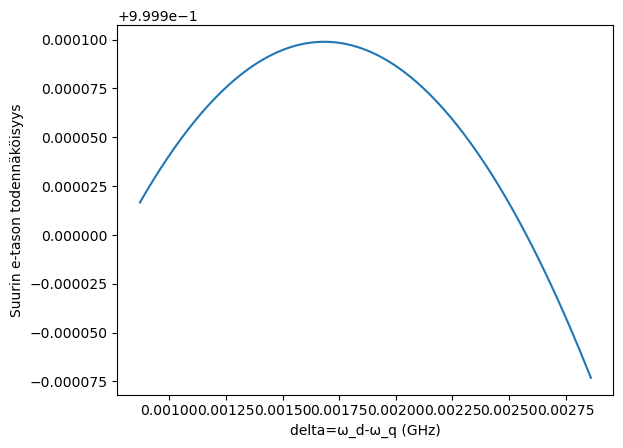

Amplitudi (GHz): 0.09122236286771505
AC-stark siirtymä (GHz): 0.0016807509096949476
E-tason suurin todennäköisyys: 0.9999988685774671
Pulssin pituus (ns): 38.34673646785279
Rabi-taajuus (fourier):  0.01454087599804528


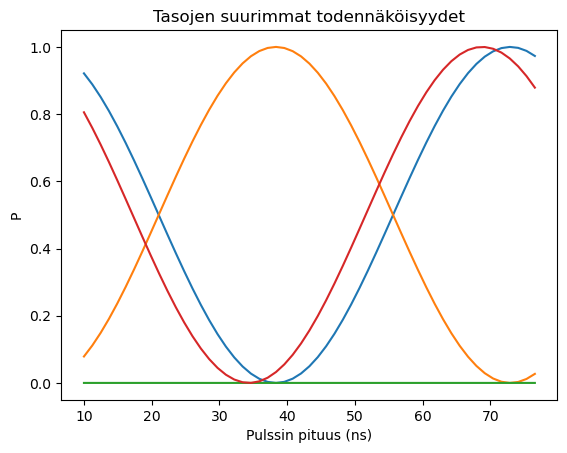

---------------------------------------------


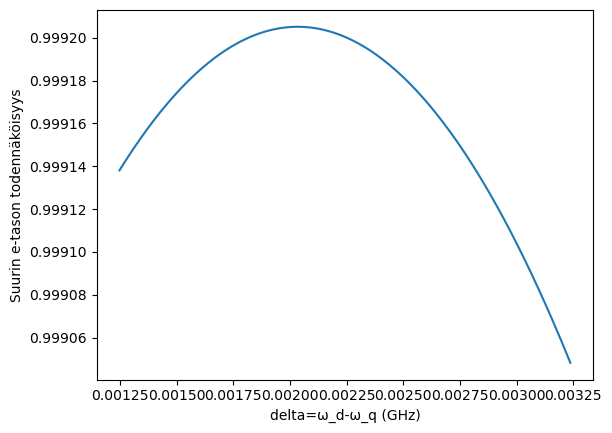

Amplitudi (GHz): 0.0999421475535996
AC-stark siirtymä (GHz): 0.0020370846933577993
E-tason suurin todennäköisyys: 0.9999994063461499
Pulssin pituus (ns): 35.881441060079624
Rabi-taajuus (fourier):  0.01590965143426547


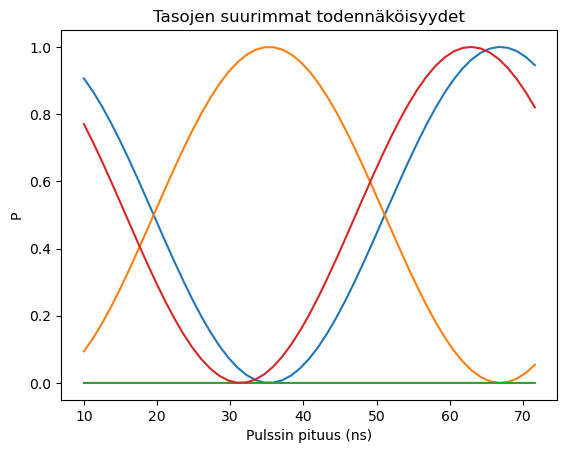

---------------------------------------------


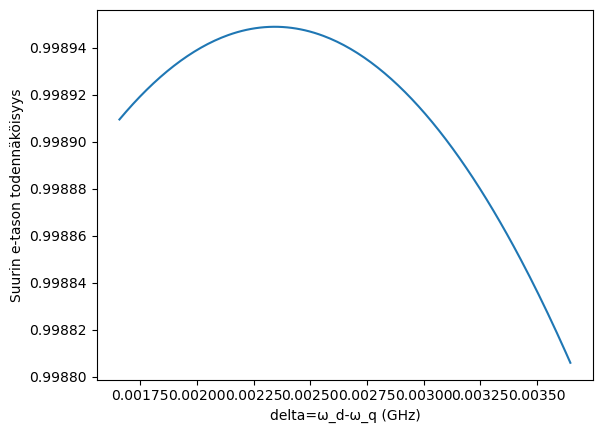

Amplitudi (GHz): 0.1086619322394841
AC-stark siirtymä (GHz): 0.0023479990335521796
E-tason suurin todennäköisyys: 0.9999960443641824
Pulssin pituus (ns): 32.183821756766
Rabi-taajuus (fourier):  0.017300684858387257


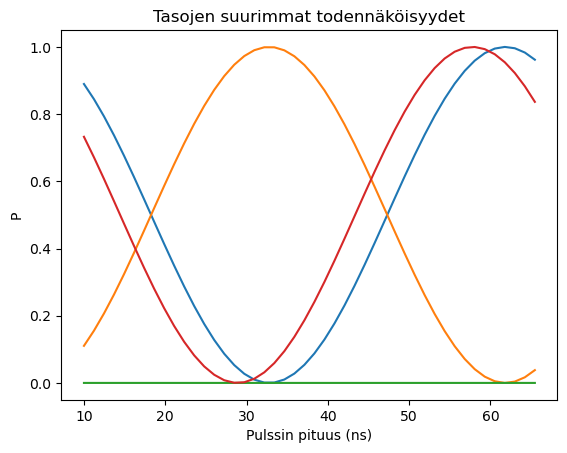

---------------------------------------------


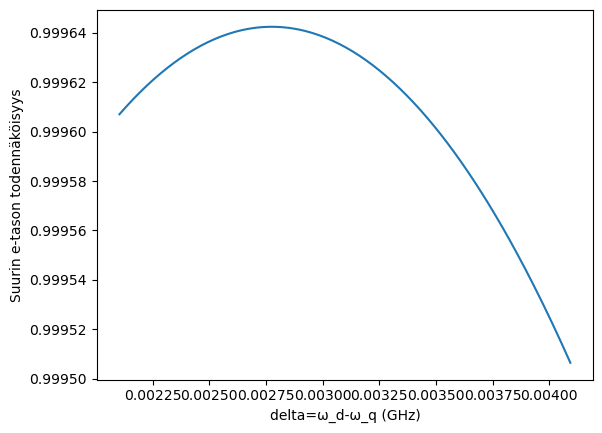

Amplitudi (GHz): 0.11738171692536864
AC-stark siirtymä (GHz): 0.0027734939302780925
E-tason suurin todennäköisyys: 0.9999982012815104
Pulssin pituus (ns): 30.951037500030537
Rabi-taajuus (fourier):  0.018696213451188437


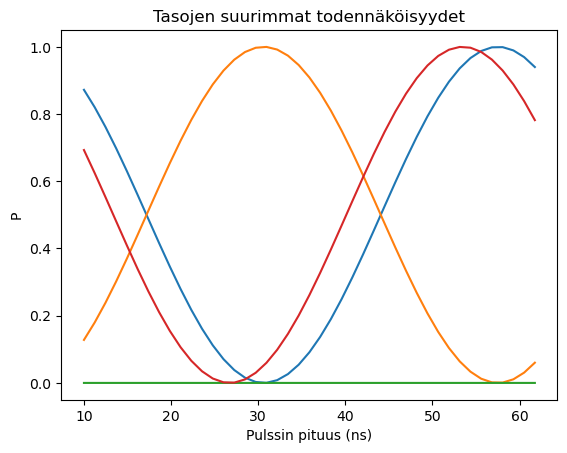

---------------------------------------------


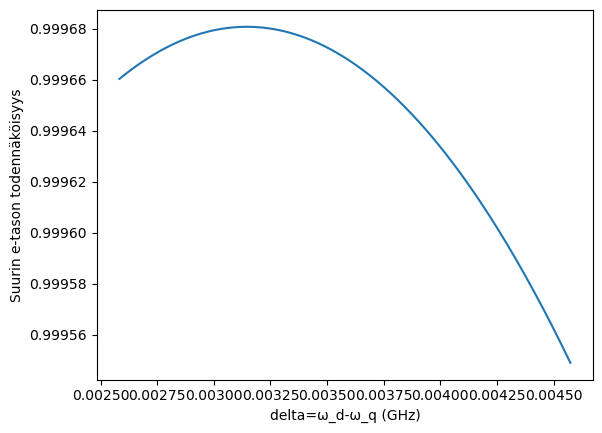

Amplitudi (GHz): 0.1261015016112532
AC-stark siirtymä (GHz): 0.0031435693835355385
E-tason suurin todennäköisyys: 0.9999956364442806
Pulssin pituus (ns): 28.485941185995163
Rabi-taajuus (fourier):  0.02008483771408708


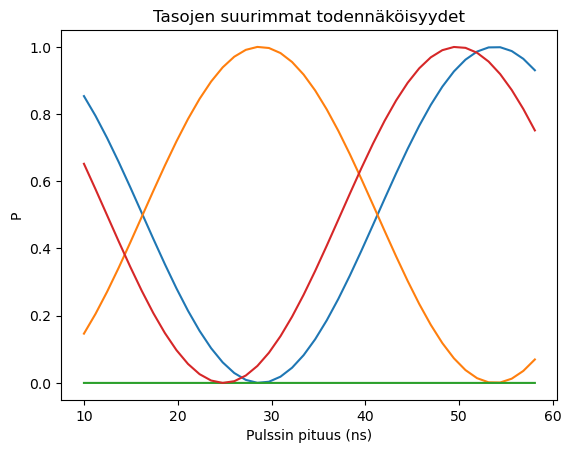

---------------------------------------------


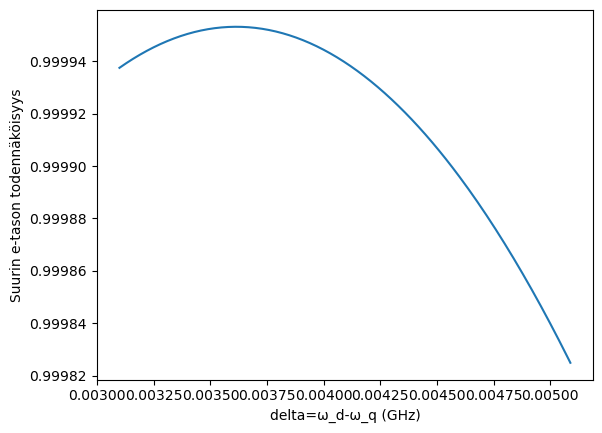

Amplitudi (GHz): 0.1348212862971377
AC-stark siirtymä (GHz): 0.0036182253933245115
E-tason suurin todennäköisyys: 0.9999697390988225
Pulssin pituus (ns): 27.25322385209111
Rabi-taajuus (fourier):  0.02146673419098309


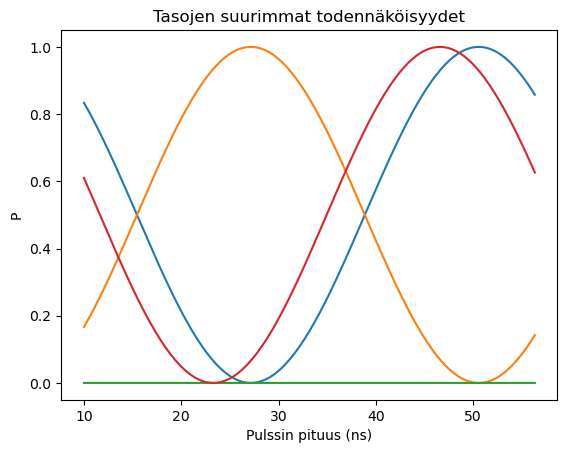

---------------------------------------------


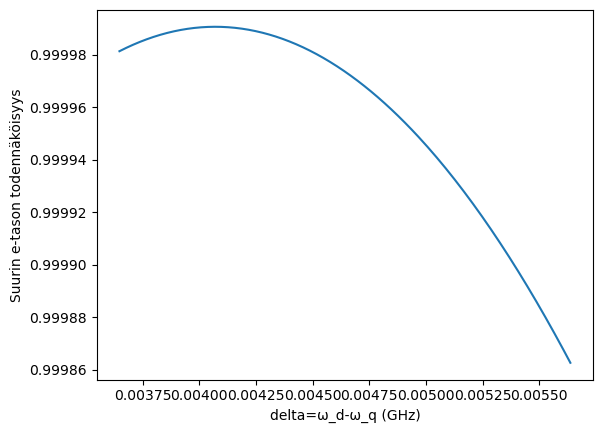

Amplitudi (GHz): 0.1435410709830222
AC-stark siirtymä (GHz): 0.004067461959645018
E-tason suurin todennäköisyys: 0.9999906615051185
Pulssin pituus (ns): 25.774098114342117
Rabi-taajuus (fourier):  0.022857939494737838


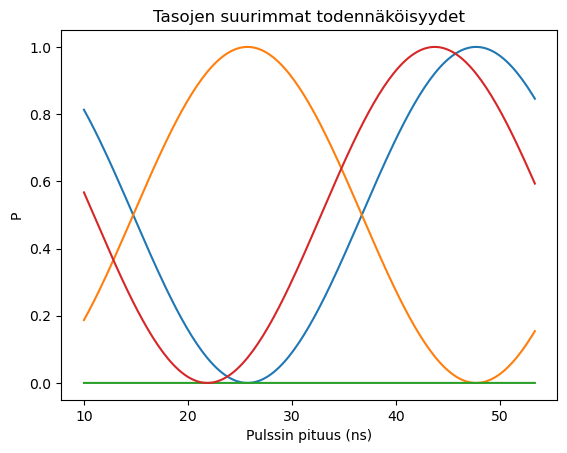

---------------------------------------------


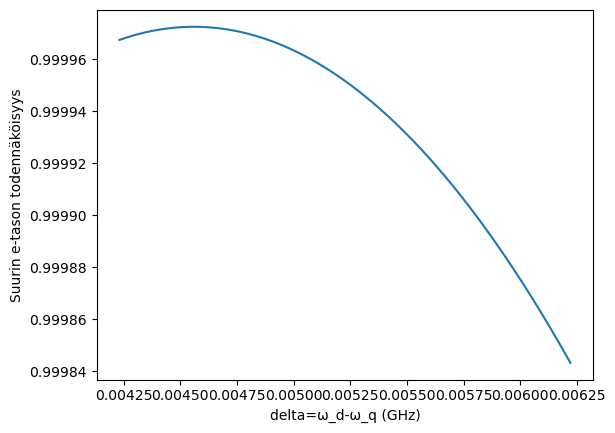

Amplitudi (GHz): 0.15226085566890676
AC-stark siirtymä (GHz): 0.004561279082497056
E-tason suurin todennäköisyys: 0.999998883719259
Pulssin pituus (ns): 24.541465017219174
Rabi-taajuus (fourier):  0.024237531981792394


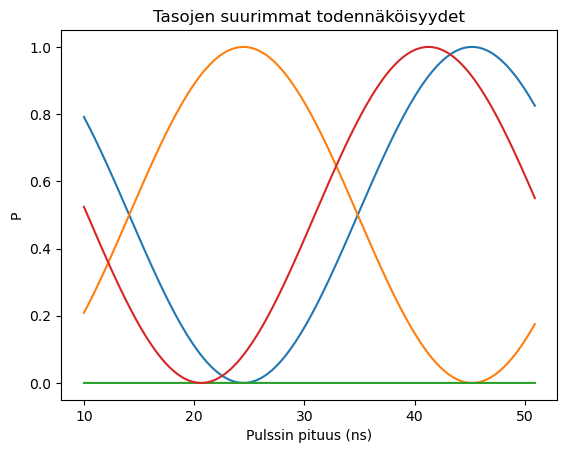

---------------------------------------------


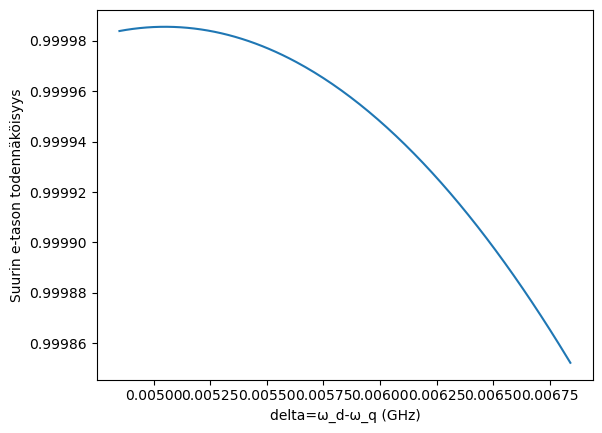

Amplitudi (GHz): 0.16098064035479126
AC-stark siirtymä (GHz): 0.005049676761880622
E-tason suurin todennäköisyys: 0.9999961196447467
Pulssin pituus (ns): 23.308882501988883
Rabi-taajuus (fourier):  0.025631336605539595


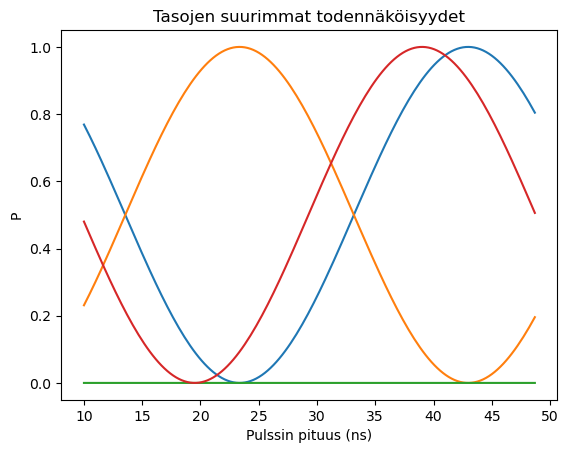

---------------------------------------------


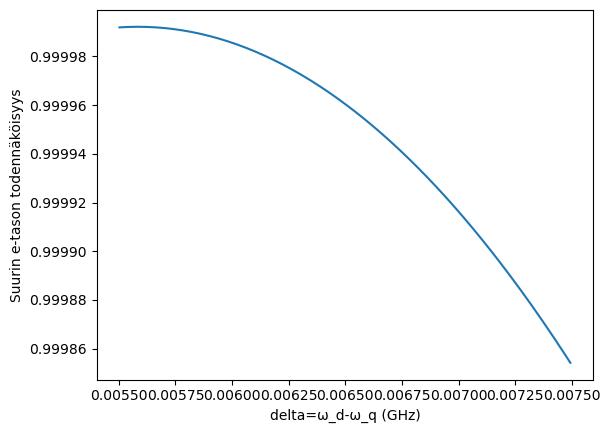

Amplitudi (GHz): 0.1697004250406758
AC-stark siirtymä (GHz): 0.005582654997795725
E-tason suurin todennäköisyys: 0.9999921722263437
Pulssin pituus (ns): 22.32278172976772
Rabi-taajuus (fourier):  0.027014150537801023


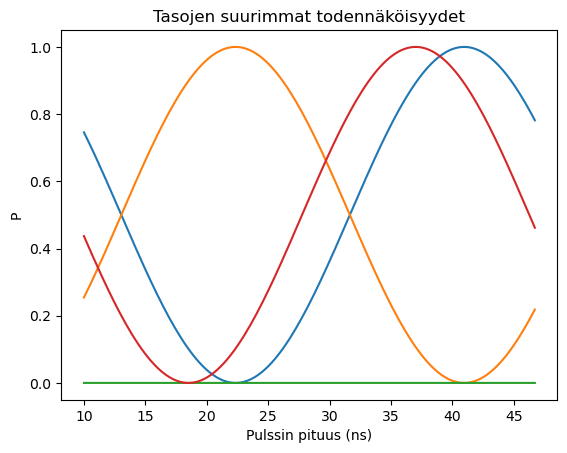

---------------------------------------------


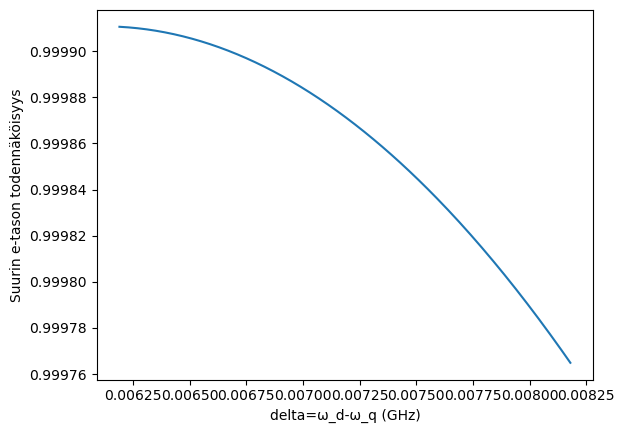

Amplitudi (GHz): 0.17842020972656034
AC-stark siirtymä (GHz): 0.006190213790242355
E-tason suurin todennäköisyys: 0.9999910610605272
Pulssin pituus (ns): 21.336689023685246
Rabi-taajuus (fourier):  0.02841472063559362


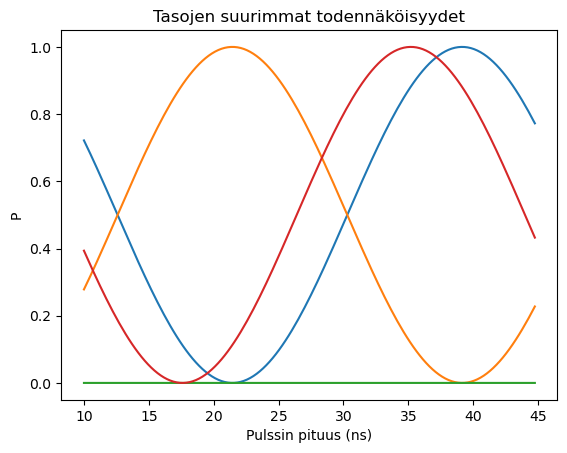

---------------------------------------------


In [ ]:
deltas = [] #AC Stark siirtymät
pulse_lengths = [] #Pulssin pituudet
max_vals = [] #Suurimmat tasojen todennäköisyydet
rabis = [] #Rabi taajuudet (fouriermuunnoksesta)
data = [] #e-tason suurimmat todennäköisyydet amplitudin ja AC-stark siirtymän suhteen
A_vals = [] #Ajavan amplitudin arvot

#Määritellään rajat amplitudille sekä simulaatioiden määrä
min_range = 0.0005
max_range = 0.0070
N_data=20
d_data=(max_range-min_range)/(N_data-1)

for i in range (0,N_data):
    
    A = qubit.frequency*(min_range+i*d_data)
    A_vals.append(A)

    AC_stark=0.2274*A**2- 0.0003122*A + 6.917e-06 #Arvaus AC-stark siirtymälle
    params=find_params(qubit, A, evolution_eigenbasis,A,AC_stark,[-100,100],100000)
    
    deltas.append(params[0])
    pulse_lengths.append(params[1])
    data.append(params[3])
    
    f_d_opt = qubit.frequency+deltas[-1] #Löydetty optimaalinen ajotaajuus

    m=10
    if A < 0.13:
        vals = pulses.sim_3_part_pulses(f_d_opt,f_ef,A,evolution_eigenbasis,dim,A/m,t_ramp=5,U_f=5)
    else:
        vals = pulses.sim_3_part_pulses(f_d_opt,f_ef,A,evolution_eigenbasis,dim,A/m,t_ramp=5,U_f=1)

    print("Amplitudi (GHz):", A)
    print("AC-stark siirtymä (GHz):", deltas[-1])

    print("E-tason suurin todennäköisyys:", vals[0])
    print("Pulssin pituus (ns):", pulse_lengths[-1])

    max_vals.append([vals[0],vals[1]])

    g_vals=np.array([arr[0] for arr in vals[3]])
    e_vals=np.array([arr[1] for arr in vals[3]])
    f_vals=np.array([arr[2] for arr in vals[3]])
    
    g_vals_offset = g_vals-0.5 #Siirretään g-tason todennäköisyyksiä puolella alaspäin, dc-komponentin minimoinniksi
    fft_vals = np.fft.rfft(g_vals_offset) #Fourier-muunnos

    #Taajuusavaruus
    freqs = np.fft.rfftfreq(len(g_vals), d=vals[4][1]-vals[4][0]) 

    magnitude = np.abs(fft_vals) #Taajuuskomponentit
    magnitude[0] = 0 #Hylätään nollataajuus/vakiokomponentti

    frequency=freqs[np.argmax(magnitude)] #Suurin g-tason aikakehityksen taajuuskomponentti=Rabi-taajuus
    print("Rabi-taajuus (fourier): ",frequency)
    rabis.append(frequency)

    n_picked = int(len(vals[3])/m) #Plottausta varten käytetty pisteiden määrä
    
    plot_vals= 0.5*(1+np.cos(2*np.pi*frequency*vals[4][:n_picked])) #Sovite Rabi-taajuudella

    plt.figure()
    plt.plot(vals[4][:n_picked], g_vals[:n_picked])
    plt.plot(vals[4][:n_picked], e_vals[:n_picked])
    plt.plot(vals[4][:n_picked], f_vals[:n_picked])
    plt.plot(vals[4][:n_picked], plot_vals)
    plt.xlabel("Pulssin pituus (ns)")
    plt.ylabel("P")
    plt.title("Tasojen suurimmat todennäköisyydet")
    plt.show()

    print("---------------------------------------------")

[np.float64(0.012744300694754308), np.float64(0.021464085380638837), np.float64(0.030183870066523365), np.float64(0.03890365475240789), np.float64(0.04762343943829242), np.float64(0.05634322412417695), np.float64(0.06506300881006147), np.float64(0.073782793495946), np.float64(0.08250257818183053), np.float64(0.09122236286771505), np.float64(0.0999421475535996), np.float64(0.1086619322394841), np.float64(0.11738171692536864), np.float64(0.1261015016112532), np.float64(0.1348212862971377), np.float64(0.1435410709830222), np.float64(0.15226085566890676), np.float64(0.16098064035479126), np.float64(0.1697004250406758), np.float64(0.17842020972656034)]


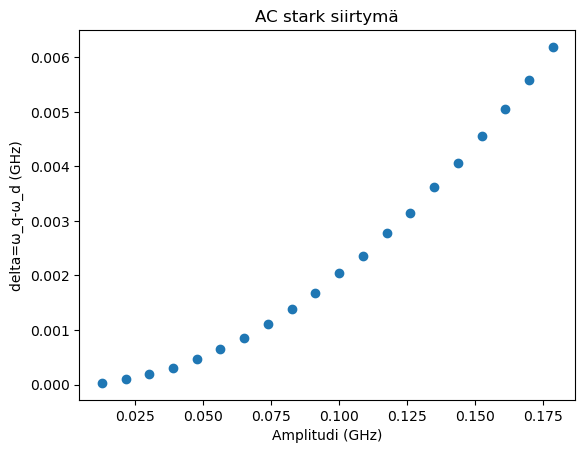

[np.float64(2.9871900648194566e-05), np.float64(9.498067552726481e-05), np.float64(0.00018467000693786622), np.float64(0.00030893989487999865), np.float64(0.0004677903393536623), np.float64(0.0006512213403588572), np.float64(0.0008592328978955829), np.float64(0.0011118250119638402), np.float64(0.0013789976825636285), np.float64(0.0016807509096949476), np.float64(0.0020370846933577993), np.float64(0.0023479990335521796), np.float64(0.0027734939302780925), np.float64(0.0031435693835355385), np.float64(0.0036182253933245115), np.float64(0.004067461959645018), np.float64(0.004561279082497056), np.float64(0.005049676761880622), np.float64(0.005582654997795725), np.float64(0.006190213790242355)]


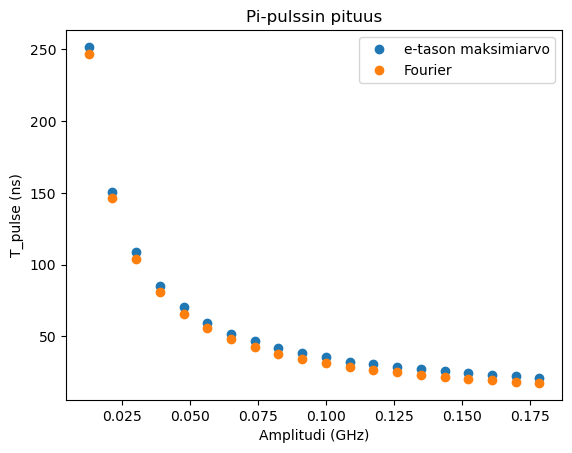

[np.float64(251.57913925957695), np.float64(150.50995676976984), np.float64(108.60313147136213), np.float64(85.18452118681144), np.float64(70.39374719403466), np.float64(59.30066332745494), np.float64(51.905221850068486), np.float64(46.974829341745675), np.float64(42.04451621876487), np.float64(38.34673646785279), np.float64(35.881441060079624), np.float64(32.183821756766), np.float64(30.951037500030537), np.float64(28.485941185995163), np.float64(27.25322385209111), np.float64(25.774098114342117), np.float64(24.541465017219174), np.float64(23.308882501988883), np.float64(22.32278172976772), np.float64(21.336689023685246)]


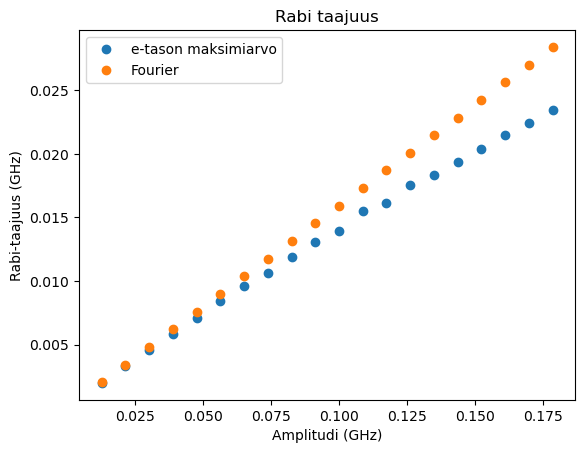

[np.float64(0.0020283208289499487), np.float64(0.0034161280170806386), np.float64(0.004806476652587316), np.float64(0.0061934138518330364), np.float64(0.007582638046325399), np.float64(0.008975089709589849), np.float64(0.010362129386467984), np.float64(0.011758880742277543), np.float64(0.013150263785857173), np.float64(0.01454087599804528), np.float64(0.01590965143426547), np.float64(0.017300684858387257), np.float64(0.018696213451188437), np.float64(0.02008483771408708), np.float64(0.02146673419098309), np.float64(0.022857939494737838), np.float64(0.024237531981792394), np.float64(0.025631336605539595), np.float64(0.027014150537801023), np.float64(0.02841472063559362)]


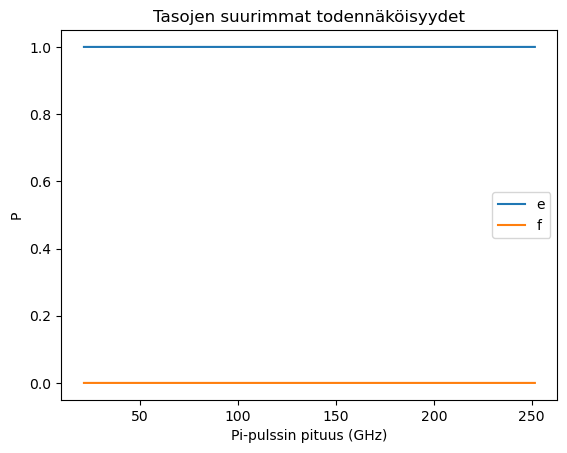

[np.float64(0.9999999025746319), np.float64(0.9999996475263531), np.float64(0.9999988750434652), np.float64(0.9999995598344724), np.float64(0.9999848424016208), np.float64(0.9999958723874995), np.float64(0.9999985690257079), np.float64(0.9999993265534349), np.float64(0.9999989442935926), np.float64(0.9999988685774671), np.float64(0.9999994063461499), np.float64(0.9999960443641824), np.float64(0.9999982012815104), np.float64(0.9999956364442806), np.float64(0.9999697390988225), np.float64(0.9999906615051185), np.float64(0.999998883719259), np.float64(0.9999961196447467), np.float64(0.9999921722263437), np.float64(0.9999910610605272)]
[np.float64(1.3436368489906216e-08), np.float64(3.930754524283052e-08), np.float64(8.012948525463497e-08), np.float64(1.371110034597807e-07), np.float64(2.1140574752935683e-07), np.float64(2.947976174719052e-07), np.float64(4.150673919663258e-07), np.float64(5.512024142776997e-07), np.float64(7.067675638842563e-07), np.float64(8.897797998202682e-07), np.floa

In [ ]:
print(A_vals)

plt.figure()
plt.plot(A_vals, deltas, 'o')
plt.xlabel("Amplitudi (GHz)")
plt.ylabel("delta=ω_q-ω_d (GHz)")
plt.title("AC stark siirtymä")
plt.show()
print(deltas)

plt.figure()
plt.plot(A_vals, pulse_lengths, 'o')
plt.xlabel("Amplitudi (GHz)")
plt.ylabel("T_pulse (ns)")
plt.title("Pi-pulssin pituus")
plt.show()
print(pulse_lengths)

plt.figure()
plt.plot(A_vals, rabis, 'o')
plt.xlabel("Amplitudi (GHz)")
plt.ylabel("Rabi-taajuus (GHz)")
plt.title("Rabi taajuus")
plt.show()
print(rabis)

e_vals=[arr[0] for arr in max_vals]
f_vals=[arr[1] for arr in max_vals]

plt.figure()
plt.plot(pulse_lengths, e_vals)
plt.plot(pulse_lengths, f_vals)
plt.legend(["e","f"])
plt.xlabel("Pi-pulssin pituus (GHz)")
plt.ylabel("P")
plt.title("Tasojen suurimmat todennäköisyydet")
plt.show()
print(e_vals)
print(f_vals)

-50
-49
-48
-47
-46
-45
-44
-43
-42
-41
-40
-39
-38
-37
-36
-35
-34
-33
-32
-31
-30
-29
-28
-27
-26
-25
-24
-23
-22
-21
-20
-19
-18
-17
-16
-15
-14
-13
-12
-11
-10
-9
-8
-7
-6
-5
-4
-3
-2
-1
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49


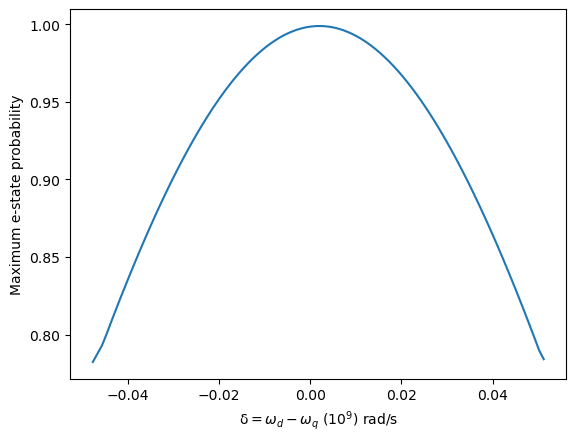

Amplitude (GHz): 0.09994214755351717
AC-stark siirtymä (GHz): 0.0022470846933540776
E-tason suurin todennäköisyys: 0.9999938184899588
Pulssin pituus (ns): 34.64878842123937
Rabi-taajuus (fourier):  0.015909782503029


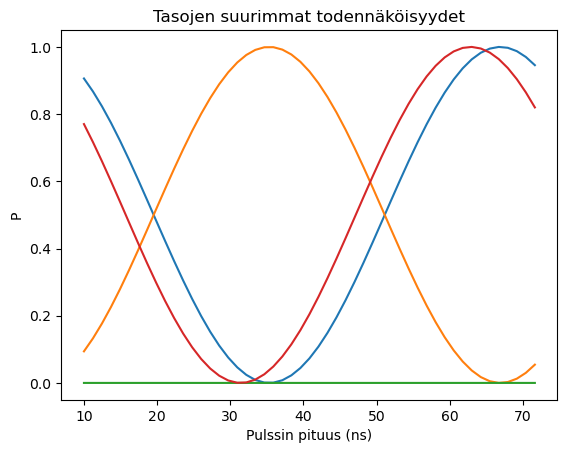

---------------------------------------------


In [21]:
deltas = [] #AC Stark siirtymät
pulse_lengths = [] #Pulssin pituudet
max_vals = [] #Suurimmat tasojen todennäköisyydet
rabis = [] #Rabi taajuudet (fouriermuunnoksesta)
data = [] #e-tason suurimmat todennäköisyydet amplitudin ja AC-stark siirtymän suhteen
A_vals = [] #Ajavan amplitudin arvot

min_range = 0.0005
max_range = 0.0070
N_data=20
d_data=(max_range-min_range)/(N_data-1)

i=10

A = qubit.frequency*(min_range+i*d_data)
A_vals.append(A)

AC_stark=0.2274*A**2- 0.0003122*A + 6.917e-06 #Arvaus AC-stark siirtymälle
params=find_params(qubit, A, evolution_eigenbasis,A,AC_stark,[-50,50],1000)

deltas.append(params[0])
pulse_lengths.append(params[1])
data.append(params[3])

f_d_opt = qubit.frequency+deltas[-1] #Löydetty optimaalinen ajotaajuus

m=10
if A < 0.13:
    vals = pulses.sim_3_part_pulses(f_d_opt,f_ef,A,evolution_eigenbasis,dim,A/m,t_ramp=5,U_f=5)
else:
    vals = pulses.sim_3_part_pulses(f_d_opt,f_ef,A,evolution_eigenbasis,dim,A/m,t_ramp=5,U_f=1)

print("Amplitude (GHz):", A)
print("AC-stark siirtymä (GHz):", deltas[-1])

print("E-tason suurin todennäköisyys:", vals[0])
print("Pulssin pituus (ns):", pulse_lengths[-1])

max_vals.append([vals[0],vals[1]])

g_vals=np.array([arr[0] for arr in vals[3]])
e_vals=np.array([arr[1] for arr in vals[3]])
f_vals=np.array([arr[2] for arr in vals[3]])

g_vals_offset = g_vals-0.5 #Siirretään g-tason todennäköisyyksiä puolella alaspäin, dc-komponentin minimoinniksi
fft_vals = np.fft.rfft(g_vals_offset) #Fourier-muunnos

#Taajuusavaruus
freqs = np.fft.rfftfreq(len(g_vals), d=vals[4][1]-vals[4][0]) 

magnitude = np.abs(fft_vals) #Taajuuskomponentit
magnitude[0] = 0 #Hylätään nollataajuus/vakiokomponentti

frequency=freqs[np.argmax(magnitude)] #Suurin g-tason aikakehityksen taajuuskomponentti=Rabi-taajuus
print("Rabi-taajuus (fourier): ",frequency)
rabis.append(frequency)

n_picked = int(len(vals[3])/m) #Plottausta varten käytetty pisteiden määrä

plot_vals= 0.5*(1+np.cos(2*np.pi*frequency*vals[4][:n_picked])) #Sovite Rabi-taajuudella

plt.figure()
plt.plot(vals[4][:n_picked], g_vals[:n_picked])
plt.plot(vals[4][:n_picked], e_vals[:n_picked])
plt.plot(vals[4][:n_picked], f_vals[:n_picked])
plt.plot(vals[4][:n_picked], plot_vals)
plt.xlabel("Pulssin pituus (ns)")
plt.ylabel("P")
plt.title("Tasojen suurimmat todennäköisyydet")
plt.show()

print("---------------------------------------------")